#PPO_LSTM2.ipynb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Colab cell 1: setup + Delayed Match-to-Sample environment

!pip -q install gymnasium matplotlib

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

OUT_DIR = "/content/dms_compare"
os.makedirs(OUT_DIR, exist_ok=True)

TOTAL_STEPS_PPO = 100_000
TOTAL_STEPS_PPO_LSTM=150_000
CHECKPOINT_EVERY = 50_000
DELAY_LEN = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class DelayedMatchToSampleEnv(gym.Env):
    """
    Symbolic delayed match-to-sample.

    Phases:
      sample -> delay -> choice

    Actions:
      0 = hold
      1 = choose A
      2 = choose B

    Observation shape: (4,)
      [sample_A, sample_B, delay_flag, choice_flag]

    Sample is shown only at the start.
    During the delay, the sample disappears.
    At choice time, the agent must remember whether the sample was A or B.
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, delay_len=8):
        super().__init__()
        self.delay_len = delay_len

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(4,), dtype=np.float32
        )

        self.sample = 0
        self.phase = "sample"
        self.delay_t = 0
        self.done = False

    def _get_obs(self):
        if self.phase == "sample":
            if self.sample == 0:
                return np.array([1, 0, 0, 0], dtype=np.float32)  # A
            else:
                return np.array([0, 1, 0, 0], dtype=np.float32)  # B
        elif self.phase == "delay":
            return np.array([0, 0, 1, 0], dtype=np.float32)
        else:
            return np.array([0, 0, 0, 1], dtype=np.float32)

    def _get_info(self, success=False):
        return {
            "sample": int(self.sample),
            "phase": self.phase,
            "success": bool(success),
        }

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.sample = int(self.np_random.choice([0, 1]))  # 0=A, 1=B
        self.phase = "sample"
        self.delay_t = 0
        self.done = False
        return self._get_obs(), self._get_info(success=False)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.phase == "sample":
            if action != 0:
                reward -= 0.02
            self.phase = "delay"
            self.delay_t = 0

        elif self.phase == "delay":
            if action != 0:
                reward -= 0.02
            self.delay_t += 1
            if self.delay_t >= self.delay_len:
                self.phase = "choice"

        else:  # choice
            correct_action = 1 if self.sample == 0 else 2
            if action == correct_action:
                reward = 1.0
                success = True
            else:
                reward = -1.0
            terminated = True
            self.done = True

        obs = self._get_obs() if not self.done else np.zeros(4, dtype=np.float32)
        return obs, reward, terminated, truncated, self._get_info(success=success)


def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)


def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret

device: cpu


⭐ new best MLP-only checkpoint saved
[DMS MLP-only PPO] step   5056 | greedy success 0.525 | greedy avg_ret -0.220 | stoch success 0.445 | stoch avg_ret -0.350 | best greedy 0.525
[DMS MLP-only PPO] step  10048 | greedy success 0.525 | greedy avg_ret -0.220 | stoch success 0.495 | stoch avg_ret -0.257 | best greedy 0.525
[DMS MLP-only PPO] step  15040 | greedy success 0.525 | greedy avg_ret -0.220 | stoch success 0.495 | stoch avg_ret -0.251 | best greedy 0.525
[DMS MLP-only PPO] step  20032 | greedy success 0.525 | greedy avg_ret -0.050 | stoch success 0.430 | stoch avg_ret -0.301 | best greedy 0.525
[DMS MLP-only PPO] step  25024 | greedy success 0.525 | greedy avg_ret -0.040 | stoch success 0.490 | stoch avg_ret -0.136 | best greedy 0.525
[DMS MLP-only PPO] step  30016 | greedy success 0.525 | greedy avg_ret -0.040 | stoch success 0.535 | stoch avg_ret -0.040 | best greedy 0.525
[DMS MLP-only PPO] step  35008 | greedy success 0.525 | greedy avg_ret -0.050 | stoch success 0.490 | sto

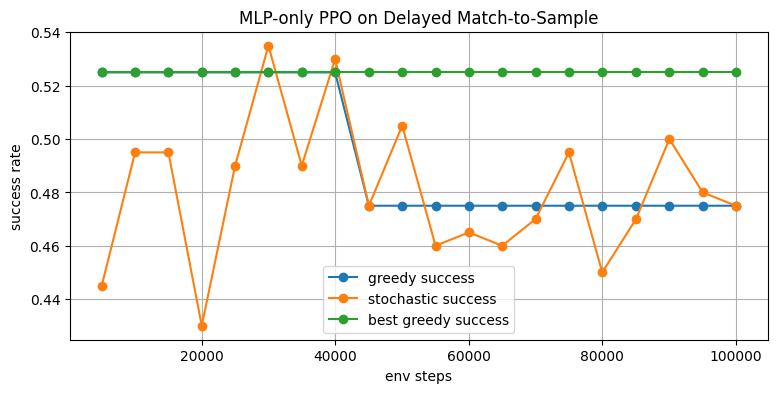

In [ ]:
# Colab cell 2: MLP-only PPO baseline

class MLPActorCritic(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.pi = nn.Linear(hidden_dim, num_actions)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z = self.body(x)
        logits = self.pi(z)
        value = self.v(z).squeeze(-1)
        return logits, value


def evaluate_mlp_policy(model, delay_len=DELAY_LEN, episodes=200, greedy=True):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, _ = model(obs_t)
                if greedy:
                    action = torch.argmax(logits, dim=-1).item()
                else:
                    dist = Categorical(logits=logits)
                    action = dist.sample().item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes


def train_mlp_ppo(total_steps=TOTAL_STEPS_PPO, delay_len=DELAY_LEN):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    model = MLPActorCritic(obs_dim=4, num_actions=env.action_space.n, hidden_dim=64).to(device)
    opt = optim.Adam(model.parameters(), lr=3e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    obs, _ = env.reset(seed=SEED)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, value = model(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                logp = dist.log_prob(action)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                ep_ret = 0.0
                obs, _ = env.reset()

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, f"dms_mlp_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, next_value = model(obs_t)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)
        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_batch = torch.stack(obs_buf)
        act_batch = torch.stack(act_buf)
        old_logp = torch.stack(logp_buf)

        for _ in range(ppo_epochs):
            logits, new_values = model(obs_batch)
            dist = Categorical(logits=logits)
            new_logp = dist.log_prob(act_batch)
            ent = dist.entropy().mean()

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv * ratio
            pg2 = -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret - new_values).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_mlp_policy(model, delay_len=delay_len, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_mlp_policy(model, delay_len=delay_len, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "dms_mlp_ppo_best.pt"),
                )
                print("⭐ new best MLP-only checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[DMS MLP-only PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


mlp_model, mlp_metrics = train_mlp_ppo()

plt.figure(figsize=(9, 4))
plt.plot(mlp_metrics["steps"], mlp_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(mlp_metrics["steps"], mlp_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(mlp_metrics["steps"], mlp_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("MLP-only PPO on Delayed Match-to-Sample")
plt.legend()
plt.grid(True)
plt.show()

⭐ new best PPO+LSTM checkpoint saved
[DMS PPO+LSTM] step   5056 | greedy success 0.450 | greedy avg_ret -0.370 | stoch success 0.415 | stoch avg_ret -0.397 | best greedy 0.450
[DMS PPO+LSTM] step  10048 | greedy success 0.450 | greedy avg_ret -0.359 | stoch success 0.410 | stoch avg_ret -0.406 | best greedy 0.450
[DMS PPO+LSTM] step  15040 | greedy success 0.450 | greedy avg_ret -0.339 | stoch success 0.445 | stoch avg_ret -0.327 | best greedy 0.450
⭐ new best PPO+LSTM checkpoint saved
[DMS PPO+LSTM] step  20032 | greedy success 0.550 | greedy avg_ret -0.130 | stoch success 0.445 | stoch avg_ret -0.326 | best greedy 0.550
[DMS PPO+LSTM] step  25024 | greedy success 0.550 | greedy avg_ret -0.090 | stoch success 0.505 | stoch avg_ret -0.195 | best greedy 0.550
[DMS PPO+LSTM] step  30016 | greedy success 0.550 | greedy avg_ret 0.010 | stoch success 0.535 | stoch avg_ret -0.124 | best greedy 0.550
[DMS PPO+LSTM] step  35008 | greedy success 0.550 | greedy avg_ret 0.010 | stoch success 0.42

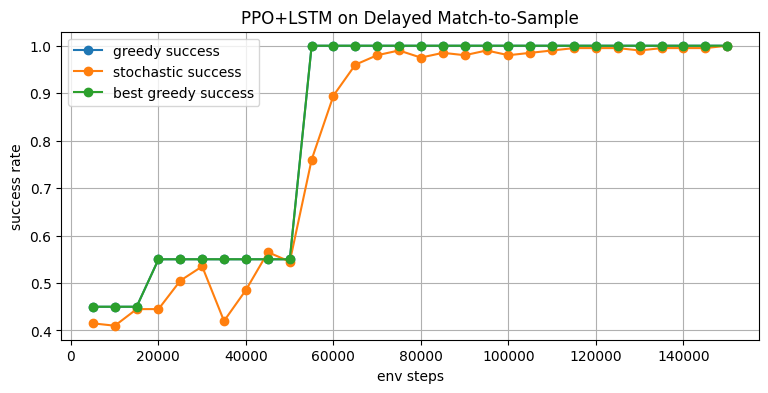

In [ ]:
# Colab cell 3: PPO + LSTM

class MLPLSTMActorCritic(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64, lstm_hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.lstm = nn.LSTM(hidden_dim, lstm_hidden, num_layers=1)
        self.pi = nn.Linear(lstm_hidden, num_actions)
        self.v = nn.Linear(lstm_hidden, 1)
        self.lstm_hidden = lstm_hidden

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        c = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        return (h, c)

    def step(self, x, hidden):
        z = self.mlp(x).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        ent = dist.entropy()
        return action, logp, ent, value, hidden

    def greedy_step(self, x, hidden):
        z = self.mlp(x).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        action = torch.argmax(logits, dim=-1)
        return action, value, hidden

    def evaluate_seq(self, obs_seq, act_seq, hidden0):
        T, B, D = obs_seq.shape
        x = obs_seq.reshape(T * B, D)
        z = self.mlp(x).view(T, B, -1)
        out, _ = self.lstm(z, hidden0)
        logits = self.pi(out)
        values = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        logp = dist.log_prob(act_seq)
        ent = dist.entropy()
        return logp, ent, values


def evaluate_lstm_policy(model, delay_len=DELAY_LEN, episodes=200, greedy=True):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 20000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False
        hidden = model.init_hidden(1)

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if greedy:
                    action, _, hidden = model.greedy_step(obs_t, hidden)
                    action = action.item()
                else:
                    action, _, _, _, hidden = model.step(obs_t, hidden)
                    action = action.item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes


def train_lstm_ppo(total_steps=TOTAL_STEPS_PPO_LSTM, delay_len=DELAY_LEN):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    model = MLPLSTMActorCritic(obs_dim=4, num_actions=env.action_space.n, hidden_dim=64, lstm_hidden=64).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    obs, _ = env.reset(seed=SEED)
    hidden = model.init_hidden(1)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
        hidden0 = (hidden[0].detach().clone(), hidden[1].detach().clone())

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                action, logp, ent, value, hidden = model.step(obs_t, hidden)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                ep_ret = 0.0
                obs, _ = env.reset()
                hidden = model.init_hidden(1)
            else:
                hidden = (hidden[0].detach(), hidden[1].detach())

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, f"dms_lstm_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, _, _, next_value, _ = model.step(obs_t, hidden)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)
        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_seq = torch.stack(obs_buf).unsqueeze(1)
        act_seq = torch.stack(act_buf).view(-1, 1)
        old_logp = torch.stack(logp_buf).view(-1, 1)
        adv_seq = adv.view(-1, 1)
        ret_seq = ret.view(-1, 1)

        for _ in range(ppo_epochs):
            new_logp, ent, new_values = model.evaluate_seq(obs_seq, act_seq, hidden0)

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv_seq * ratio
            pg2 = -adv_seq * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret_seq - new_values).pow(2).mean()
            ent_loss = ent.mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_lstm_policy(model, delay_len=delay_len, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_lstm_policy(model, delay_len=delay_len, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "dms_lstm_ppo_best.pt"),
                )
                print("⭐ new best PPO+LSTM checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[DMS PPO+LSTM] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


lstm_model, lstm_metrics = train_lstm_ppo()

plt.figure(figsize=(9, 4))
plt.plot(lstm_metrics["steps"], lstm_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(lstm_metrics["steps"], lstm_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(lstm_metrics["steps"], lstm_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("PPO+LSTM on Delayed Match-to-Sample")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Colab cell: Grad-CAM + LSTM hidden-state heat map for CNN+LSTM Image T-Maze
#
# Assumes you already trained a model with the CNNLSTMActorCritic class and
# ImageTMaze3ActionEnv from earlier cells.
#
# This cell:
# 1. wraps the model so we can capture last-conv activations
# 2. runs one episode with greedy policy
# 3. computes Grad-CAM on selected timesteps
# 4. plots LSTM hidden-state heatmap over time
# 5. overlays Grad-CAM on the input frame
#
# If your trained model variable has a different name, change MODEL below.

!pip -q install matplotlib pillow

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ------------------------------------------------------------------
# Pick your trained model here
# ------------------------------------------------------------------
# Example:
# MODEL = cnn_lstm_model
MODEL = cnn_lstm_model

MODEL.eval()


# ------------------------------------------------------------------
# Utilities
# ------------------------------------------------------------------
def tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def chw_to_hwc(img_chw):
    return np.transpose(img_chw, (1, 2, 0))

def normalize_map(x):
    x = x - x.min()
    denom = x.max() - x.min()
    if denom < 1e-8:
        return np.zeros_like(x)
    return x / denom

def overlay_heatmap_on_image(img_hwc, heatmap, alpha=0.45):
    """
    img_hwc: float image in [0,1], shape [H,W,3]
    heatmap: float map in [H,W], normalized to [0,1]
    """
    cmap = plt.get_cmap("jet")
    heat_rgb = cmap(heatmap)[..., :3]
    out = (1 - alpha) * img_hwc + alpha * heat_rgb
    return np.clip(out, 0.0, 1.0)


# ------------------------------------------------------------------
# Grad-CAM wrapper for the CNN encoder
# ------------------------------------------------------------------
class CNNLSTMGradCAMWrapper(torch.nn.Module):
    def __init__(self, actor_critic):
        super().__init__()
        self.model = actor_critic
        self.activations = None
        self.gradients = None

        # We want the last conv feature map before flatten.
        # Earlier code used:
        # Conv2d, ReLU, Conv2d, ReLU, Conv2d, ReLU, Flatten
        # So index 4 is the last Conv2d.
        target_layer = self.model.enc.net[4]

        def forward_hook(module, inputs, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self._fh = target_layer.register_forward_hook(forward_hook)
        self._bh = target_layer.register_full_backward_hook(backward_hook)

    def remove_hooks(self):
        self._fh.remove()
        self._bh.remove()

    def forward_with_hidden(self, obs_t, hidden):
        """
        Forward pass that also preserves the hidden transition exactly like greedy_step.
        Returns logits, value, next_hidden.
        """
        z = self.model.fc(self.model.enc(obs_t)).unsqueeze(0)
        out, next_hidden = self.model.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.model.pi(out)
        value = self.model.v(out).squeeze(-1)
        return logits, value, next_hidden

    def gradcam_for_action(self, obs_t, hidden, action_idx=None):
        """
        Compute Grad-CAM for one observation and one recurrent hidden state.
        action_idx:
          None => use greedy action
          int  => use provided action index
        Returns:
          cam [H,W], logits [A], value scalar, chosen action int, next_hidden
        """
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None

        logits, value, next_hidden = self.forward_with_hidden(obs_t, hidden)

        if action_idx is None:
            action_idx = int(torch.argmax(logits, dim=-1).item())

        score = logits[0, action_idx]
        score.backward(retain_graph=True)

        # activations/grads shape: [B,C,H,W]
        acts = self.activations.detach()[0]
        grads = self.gradients.detach()[0]

        # Grad-CAM weights: global-average-pool gradients over spatial dims
        weights = grads.mean(dim=(1, 2), keepdim=True)   # [C,1,1]
        cam = (weights * acts).sum(dim=0)                # [H,W]
        cam = F.relu(cam)

        cam = cam.cpu().numpy()
        cam = normalize_map(cam)

        # upscale to input resolution
        H_in, W_in = obs_t.shape[-2:]
        cam_up = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
        cam_up = F.interpolate(cam_up, size=(H_in, W_in), mode="bilinear", align_corners=False)
        cam_up = cam_up.squeeze().cpu().numpy()
        cam_up = normalize_map(cam_up)

        return cam_up, logits.detach().cpu().numpy()[0], float(value.item()), action_idx, next_hidden


wrapper = CNNLSTMGradCAMWrapper(MODEL)


# ------------------------------------------------------------------
# Run one greedy episode and collect hidden states / frames
# ------------------------------------------------------------------
def rollout_episode_with_hidden(model, seed=123):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
        render_mode="rgb_array",
    )

    obs, info = env.reset(seed=seed)
    hidden = model.init_hidden(1)

    records = []
    done = False
    t = 0

    while not done:
        obs_t = tensor_obs(obs)
        with torch.no_grad():
            action, _, hidden_next = model.greedy_step(obs_t, hidden)

            # Also record logits/value from the same hidden state
            z = model.fc(model.enc(obs_t)).unsqueeze(0)
            out, _ = model.lstm(z, hidden)
            out = out.squeeze(0)
            logits = model.pi(out)
            value = model.v(out).squeeze(-1)

        records.append({
            "t": t,
            "obs": obs.copy(),
            "frame": env.render().copy(),
            "hidden_h": hidden[0].detach().cpu().numpy()[0, 0].copy(),
            "hidden_c": hidden[1].detach().cpu().numpy()[0, 0].copy(),
            "logits": logits.detach().cpu().numpy()[0].copy(),
            "value": float(value.item()),
            "action": int(action.item()),
            "agent_pos": info.get("agent_pos"),
            "cue": info.get("cue"),
            "junction": info.get("junction"),
        })

        obs, reward, term, trunc, info = env.step(int(action.item()))
        hidden = (hidden_next[0].detach(), hidden_next[1].detach())
        done = term or trunc
        t += 1

    env.close()
    return records


records = rollout_episode_with_hidden(MODEL, seed=SEED + 77)

print("Episode length:", len(records))
print("Cue:", records[0]["cue"])
for r in records:
    print(
        f"t={r['t']} action={r['action']} "
        f"logits={np.round(r['logits'], 3)} "
        f"value={r['value']:.3f} "
        f"pos={r['agent_pos']} junction={r['junction']}"
    )


# ------------------------------------------------------------------
# Hidden-state heat maps
# ------------------------------------------------------------------
def plot_hidden_state_heatmaps(records):
    H = np.stack([r["hidden_h"] for r in records], axis=0)  # [T, hidden]
    C = np.stack([r["hidden_c"] for r in records], axis=0)  # [T, hidden]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    im0 = axes[0].imshow(H.T, aspect="auto", interpolation="nearest")
    axes[0].set_title("LSTM hidden state h over time")
    axes[0].set_xlabel("time step")
    axes[0].set_ylabel("hidden unit")
    for t, r in enumerate(records):
        if r["junction"]:
            axes[0].axvline(t, color="white", linestyle="--", linewidth=1)

    im1 = axes[1].imshow(C.T, aspect="auto", interpolation="nearest")
    axes[1].set_title("LSTM cell state c over time")
    axes[1].set_xlabel("time step")
    axes[1].set_ylabel("cell unit")
    for t, r in enumerate(records):
        if r["junction"]:
            axes[1].axvline(t, color="white", linestyle="--", linewidth=1)

    plt.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)
    plt.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)
    plt.show()


plot_hidden_state_heatmaps(records)


# ------------------------------------------------------------------
# Pick interesting timesteps for Grad-CAM
# Usually:
# - t=0 : cue visible
# - middle corridor
# - junction step
# ------------------------------------------------------------------
def choose_key_timesteps(records):
    key = []
    if len(records) > 0:
        key.append(0)

    if len(records) > 2:
        key.append(len(records) // 2)

    junction_ts = [r["t"] for r in records if r["junction"]]
    if len(junction_ts) > 0:
        key.append(junction_ts[0])

    # unique and sorted
    key = sorted(set(key))
    return key


key_ts = choose_key_timesteps(records)
print("Selected timesteps for Grad-CAM:", key_ts)


# ------------------------------------------------------------------
# Recreate hidden states at selected timesteps and compute Grad-CAM
# ------------------------------------------------------------------
def get_hidden_before_t(model, records, t_target):
    """
    Replays from start until just before t_target action.
    Returns hidden state corresponding to records[t_target].
    """
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
        render_mode="rgb_array",
    )
    obs, _ = env.reset(seed=SEED + 77)
    hidden = model.init_hidden(1)

    for t in range(t_target):
        obs_t = tensor_obs(obs)
        with torch.no_grad():
            action, _, hidden_next = model.greedy_step(obs_t, hidden)
        obs, reward, term, trunc, info = env.step(int(action.item()))
        hidden = (hidden_next[0].detach(), hidden_next[1].detach())

    env.close()
    return hidden


def plot_gradcam_panels(wrapper, model, records, timesteps):
    n = len(timesteps)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n), constrained_layout=True)
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, t in enumerate(timesteps):
        rec = records[t]
        obs = rec["obs"]
        obs_t = tensor_obs(obs)
        hidden = get_hidden_before_t(model, records, t)

        cam, logits, value, action_idx, _ = wrapper.gradcam_for_action(obs_t, hidden, action_idx=None)

        img_hwc = chw_to_hwc(obs)
        overlay = overlay_heatmap_on_image(img_hwc, cam, alpha=0.45)

        # raw obs
        axes[row, 0].imshow(img_hwc)
        axes[row, 0].set_title(
            f"Obs t={t}\ncue={rec['cue']} pos={rec['agent_pos']} junction={rec['junction']}"
        )
        axes[row, 0].axis("off")

        # heatmap only
        axes[row, 1].imshow(cam, cmap="jet")
        axes[row, 1].set_title(
            f"Grad-CAM t={t}\naction={action_idx} logits={np.round(logits,2)} value={value:.2f}"
        )
        axes[row, 1].axis("off")

        # overlay
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title("Overlay")
        axes[row, 2].axis("off")

    plt.show()


plot_gradcam_panels(wrapper, MODEL, records, key_ts)


# ------------------------------------------------------------------
# Optional: compare cue A vs cue B episodes
# Finds one left-cue and one right-cue episode and plots first frame CAM
# ------------------------------------------------------------------
def rollout_until_cue(model, seed):
    recs = rollout_episode_with_hidden(model, seed=seed)
    return recs

def compare_two_cues(wrapper, model, seed_left=1001, seed_right=1002, max_tries=100):
    left_recs = None
    right_recs = None

    s = seed_left
    for _ in range(max_tries):
        recs = rollout_episode_with_hidden(model, seed=s)
        cue = recs[0]["cue"]
        if cue == -1:
            left_recs = recs
            break
        s += 1

    s = seed_right
    for _ in range(max_tries):
        recs = rollout_episode_with_hidden(model, seed=s)
        cue = recs[0]["cue"]
        if cue == 1:
            right_recs = recs
            break
        s += 1

    if left_recs is None or right_recs is None:
        print("Could not find both cue types.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

    for row, recs in enumerate([left_recs, right_recs]):
        obs = recs[0]["obs"]
        obs_t = tensor_obs(obs)
        hidden = MODEL.init_hidden(1)
        cam, logits, value, action_idx, _ = wrapper.gradcam_for_action(obs_t, hidden, action_idx=None)

        img_hwc = chw_to_hwc(obs)
        overlay = overlay_heatmap_on_image(img_hwc, cam, alpha=0.45)

        label = "LEFT cue" if recs[0]["cue"] == -1 else "RIGHT cue"

        axes[row, 0].imshow(img_hwc)
        axes[row, 0].set_title(f"{label}: raw obs")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(cam, cmap="jet")
        axes[row, 1].set_title(f"{label}: Grad-CAM")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f"{label}: overlay")
        axes[row, 2].axis("off")

    plt.show()


compare_two_cues(wrapper, MODEL)


# ------------------------------------------------------------------
# Optional: plot action logits over time
# ------------------------------------------------------------------
def plot_logits_over_time(records):
    logits = np.stack([r["logits"] for r in records], axis=0)  # [T, A]
    plt.figure(figsize=(10, 4))
    for a in range(logits.shape[1]):
        plt.plot(logits[:, a], marker="o", label=f"action {a}")
    for t, r in enumerate(records):
        if r["junction"]:
            plt.axvline(t, color="black", linestyle="--", linewidth=1)
    plt.xlabel("time step")
    plt.ylabel("logit")
    plt.title("Policy logits over time")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_logits_over_time(records)


# ------------------------------------------------------------------
# Cleanup note
# ------------------------------------------------------------------
# When done:
# wrapper.remove_hooks()

In [ ]:
# Colab cell: hidden-state heat map for cue retention
#
# Assumes you already have:
# - a trained recurrent model, e.g. cnn_lstm_model
# - ImageTMaze3ActionEnv defined
# - device, SEED, CORRIDOR_LEN, LOCAL_VIEW, IMG_SIZE, MAX_EP_STEPS defined
#
# Change MODEL below if needed.

import numpy as np
import matplotlib.pyplot as plt
import torch

MODEL = cnn_lstm_model
MODEL.eval()

def tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def collect_hidden_trajectories(model, n_episodes=40, greedy=True, seed_start=5000):
    """
    Collect hidden-state trajectories grouped by cue.
    Returns:
      left_h, right_h: lists of arrays [T, H]
      left_c, right_c: lists of arrays [T, H]
      meta: list of dicts
    """
    left_h, right_h = [], []
    left_c, right_c = [], []
    meta = []

    for ep in range(n_episodes):
        env = ImageTMaze3ActionEnv(
            corridor_length=CORRIDOR_LEN,
            view_size=LOCAL_VIEW,
            image_size=IMG_SIZE,
            max_steps=MAX_EP_STEPS,
            render_mode="rgb_array",
        )
        obs, info = env.reset(seed=seed_start + ep)
        cue = int(info["cue"])

        hidden = model.init_hidden(1)
        done = False

        hs = []
        cs = []
        actions = []
        junction_ts = []

        t = 0
        while not done:
            # record hidden state BEFORE action
            hs.append(hidden[0].detach().cpu().numpy()[0, 0].copy())
            cs.append(hidden[1].detach().cpu().numpy()[0, 0].copy())

            if info.get("junction", False):
                junction_ts.append(t)

            obs_t = tensor_obs(obs)
            with torch.no_grad():
                if greedy:
                    action, _, hidden_next = model.greedy_step(obs_t, hidden)
                    action = int(action.item())
                else:
                    action, _, _, _, hidden_next = model.step(obs_t, hidden)
                    action = int(action.item())

            actions.append(action)
            obs, reward, term, trunc, info = env.step(action)
            done = term or trunc
            hidden = (hidden_next[0].detach(), hidden_next[1].detach())
            t += 1

        env.close()

        hs = np.stack(hs, axis=0)   # [T, H]
        cs = np.stack(cs, axis=0)   # [T, H]

        if cue == -1:
            left_h.append(hs)
            left_c.append(cs)
        else:
            right_h.append(hs)
            right_c.append(cs)

        meta.append({
            "cue": cue,
            "actions": actions,
            "junction_ts": junction_ts,
            "length": len(actions),
        })

    return left_h, right_h, left_c, right_c, meta

def stack_mean(trajs):
    """
    Average trajectories of identical length.
    For T-maze these should usually match in length.
    """
    min_len = min(x.shape[0] for x in trajs)
    arr = np.stack([x[:min_len] for x in trajs], axis=0)  # [N,T,H]
    mean = arr.mean(axis=0)                                # [T,H]
    std = arr.std(axis=0)
    return mean, std, arr

def separability_score(arr_left, arr_right):
    """
    Simple cue separability over time:
      ||mean_left(t) - mean_right(t)|| / pooled_std
    Returns score per timestep.
    """
    mu_l = arr_left.mean(axis=0)   # [T,H]
    mu_r = arr_right.mean(axis=0)  # [T,H]
    sd_l = arr_left.std(axis=0)
    sd_r = arr_right.std(axis=0)

    pooled = np.sqrt((sd_l**2 + sd_r**2) / 2.0 + 1e-8)   # [T,H]
    z = np.abs(mu_l - mu_r) / pooled
    score = z.mean(axis=1)   # [T]
    return score

def plot_hidden_heatmaps(left_mean, right_mean, title_prefix="h"):
    """
    left_mean/right_mean shape [T,H]
    """
    diff = left_mean - right_mean

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

    im0 = axes[0].imshow(left_mean.T, aspect="auto", interpolation="nearest")
    axes[0].set_title(f"{title_prefix}: mean hidden state for LEFT cue")
    axes[0].set_xlabel("time step")
    axes[0].set_ylabel("hidden unit")
    plt.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)

    im1 = axes[1].imshow(right_mean.T, aspect="auto", interpolation="nearest")
    axes[1].set_title(f"{title_prefix}: mean hidden state for RIGHT cue")
    axes[1].set_xlabel("time step")
    axes[1].set_ylabel("hidden unit")
    plt.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)

    im2 = axes[2].imshow(diff.T, aspect="auto", interpolation="nearest", cmap="coolwarm")
    axes[2].set_title(f"{title_prefix}: LEFT minus RIGHT hidden state")
    axes[2].set_xlabel("time step")
    axes[2].set_ylabel("hidden unit")
    plt.colorbar(im2, ax=axes[2], fraction=0.02, pad=0.02)

    plt.show()

def plot_separability(score_h, score_c):
    plt.figure(figsize=(10, 4))
    plt.plot(score_h, marker="o", label="hidden h separability")
    plt.plot(score_c, marker="o", label="cell c separability")
    plt.xlabel("time step")
    plt.ylabel("cue separability score")
    plt.title("Cue retention over time")
    plt.grid(True)
    plt.legend()
    plt.show()

# ------------------------------------------------------------
# Run collection
# ------------------------------------------------------------
left_h, right_h, left_c, right_c, meta = collect_hidden_trajectories(
    MODEL,
    n_episodes=40,
    greedy=True,
    seed_start=SEED + 5000
)

print("left episodes :", len(left_h))
print("right episodes:", len(right_h))

left_h_mean, left_h_std, left_h_arr = stack_mean(left_h)
right_h_mean, right_h_std, right_h_arr = stack_mean(right_h)

left_c_mean, left_c_std, left_c_arr = stack_mean(left_c)
right_c_mean, right_c_std, right_c_arr = stack_mean(right_c)

# ------------------------------------------------------------
# Plot heat maps
# ------------------------------------------------------------
plot_hidden_heatmaps(left_h_mean, right_h_mean, title_prefix="LSTM hidden h")
plot_hidden_heatmaps(left_c_mean, right_c_mean, title_prefix="LSTM cell c")

# ------------------------------------------------------------
# Plot cue separability
# ------------------------------------------------------------
score_h = separability_score(left_h_arr, right_h_arr)
score_c = separability_score(left_c_arr, right_c_arr)
plot_separability(score_h, score_c)

# ------------------------------------------------------------
# Print a simple summary
# ------------------------------------------------------------
print("Hidden-state cue separability by timestep (h):", np.round(score_h, 3))
print("Cell-state cue separability by timestep (c):  ", np.round(score_c, 3))

How to read it:

* If cue retention is good, the LEFT and RIGHT heat maps should look visibly different not only at t=0, but also through later timesteps.
* The LEFT minus RIGHT plot should show structured differences that persist until the junction.
* The cue separability score should stay clearly above zero across the corridor. If it spikes at t=0 and then collapses, the model is seeing the cue but not retaining it.

A strong next comparison is to run this on:

* a weak checkpoint
* a solved checkpoint

and compare how long the cue-separation persists.

BabyAI/MiniGrid use a CFG instruction set and uses a GRU network and is a 10yo(2016) precursor to attention.

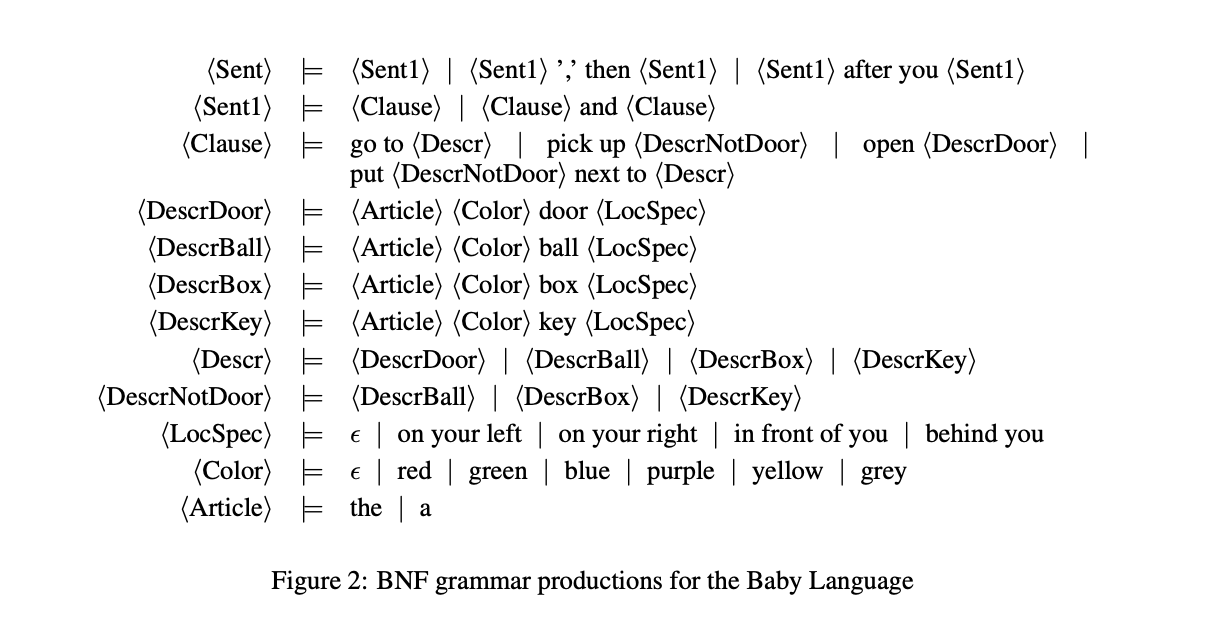

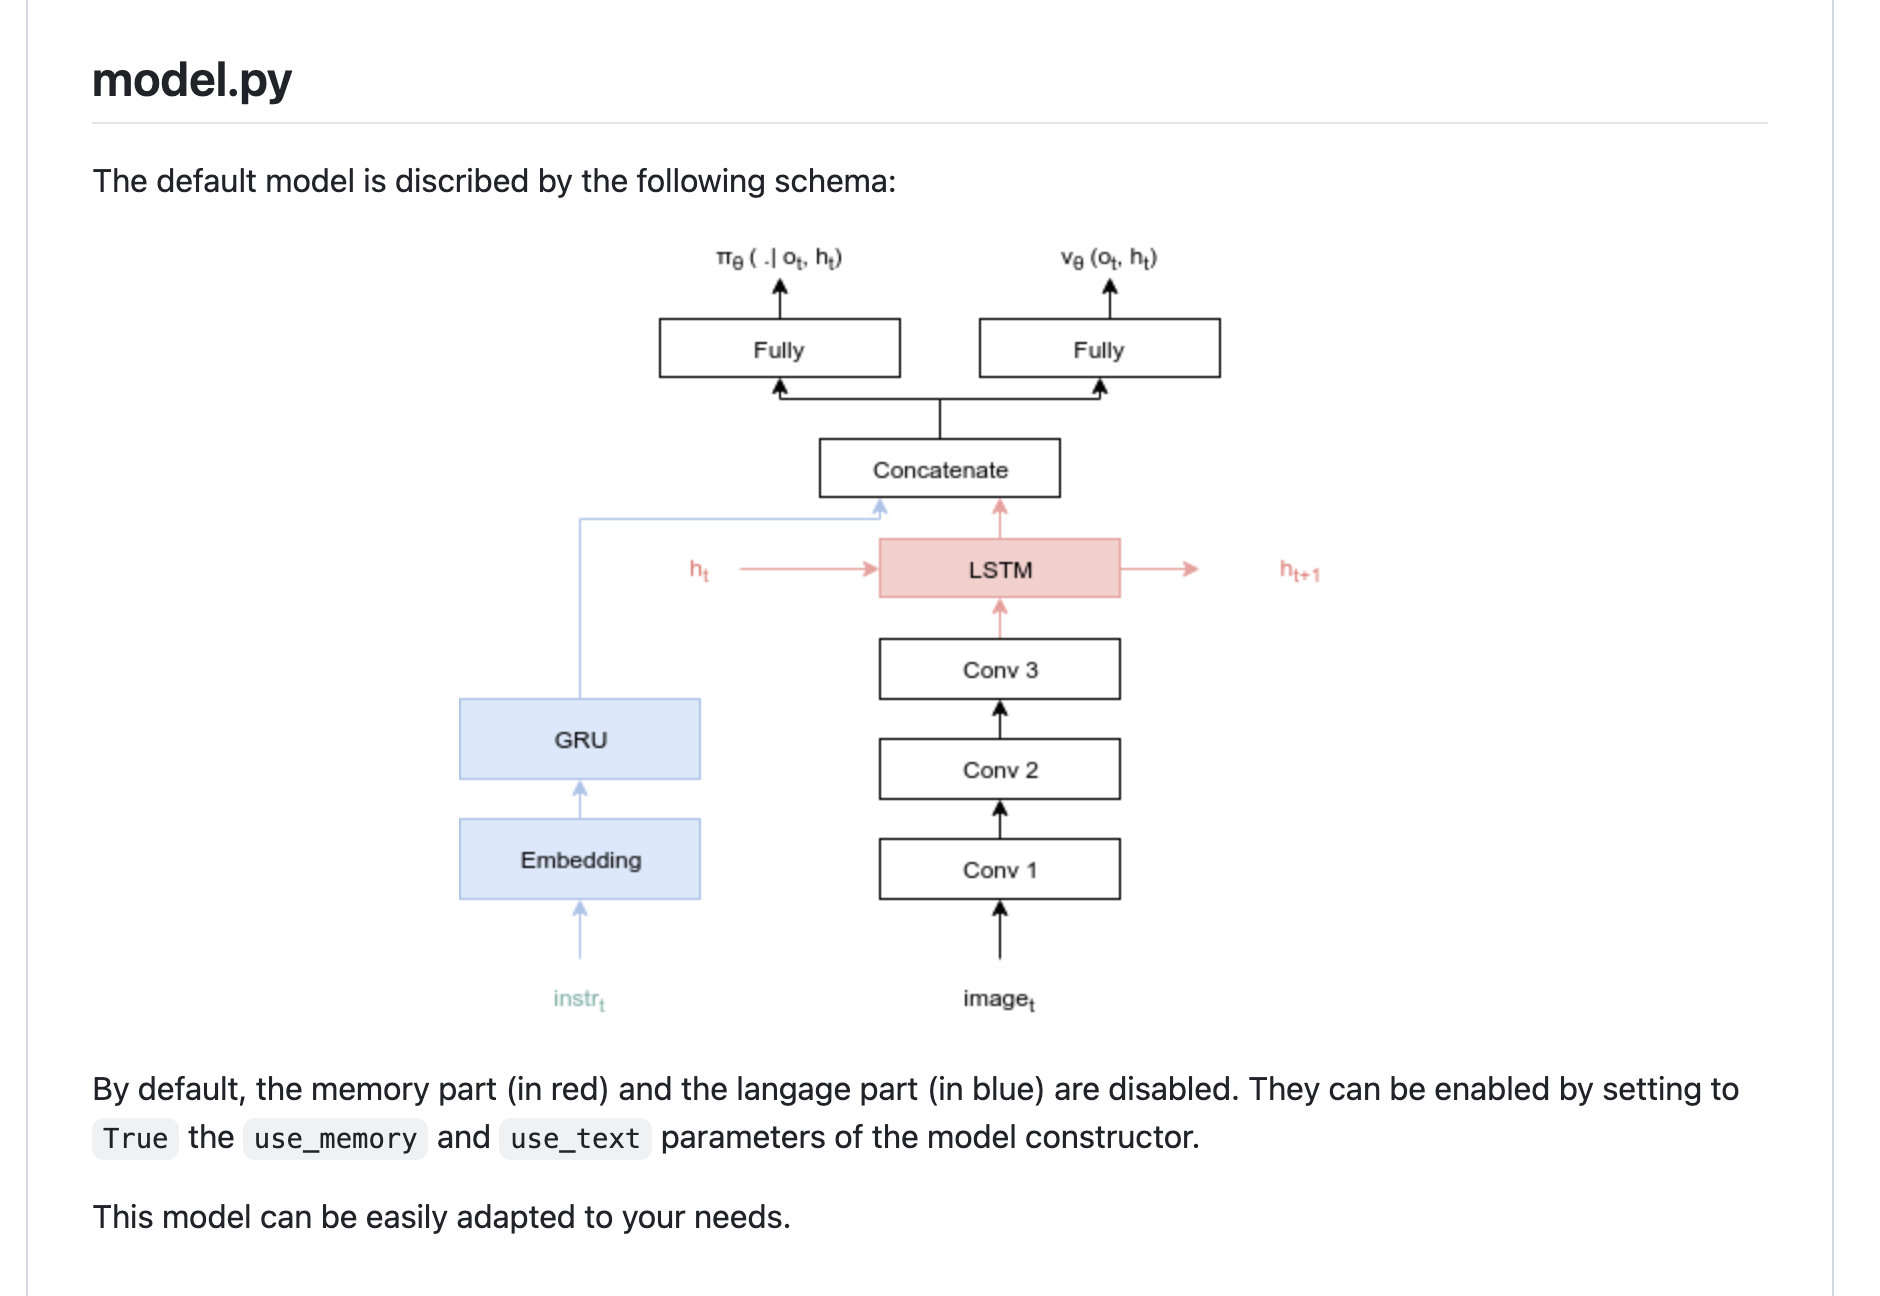

BabyAI is considered a solved problem with the baby instruction set.

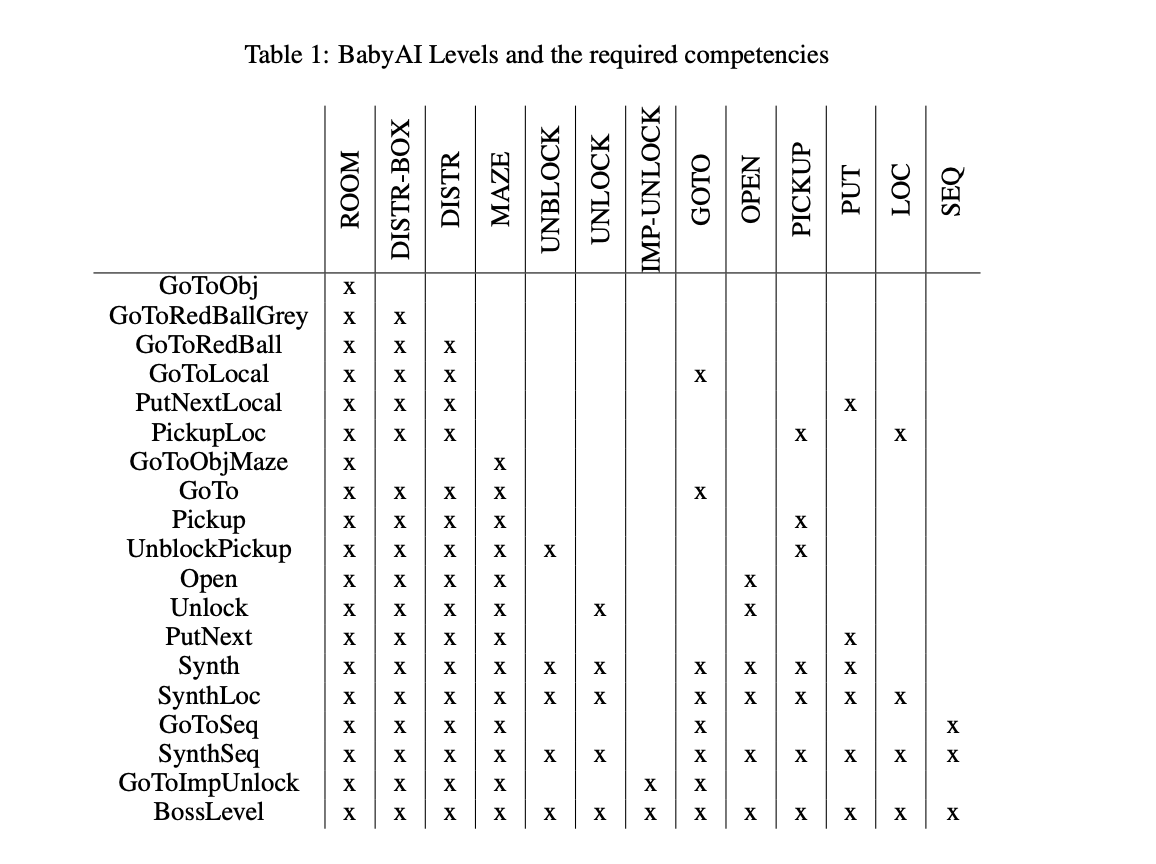

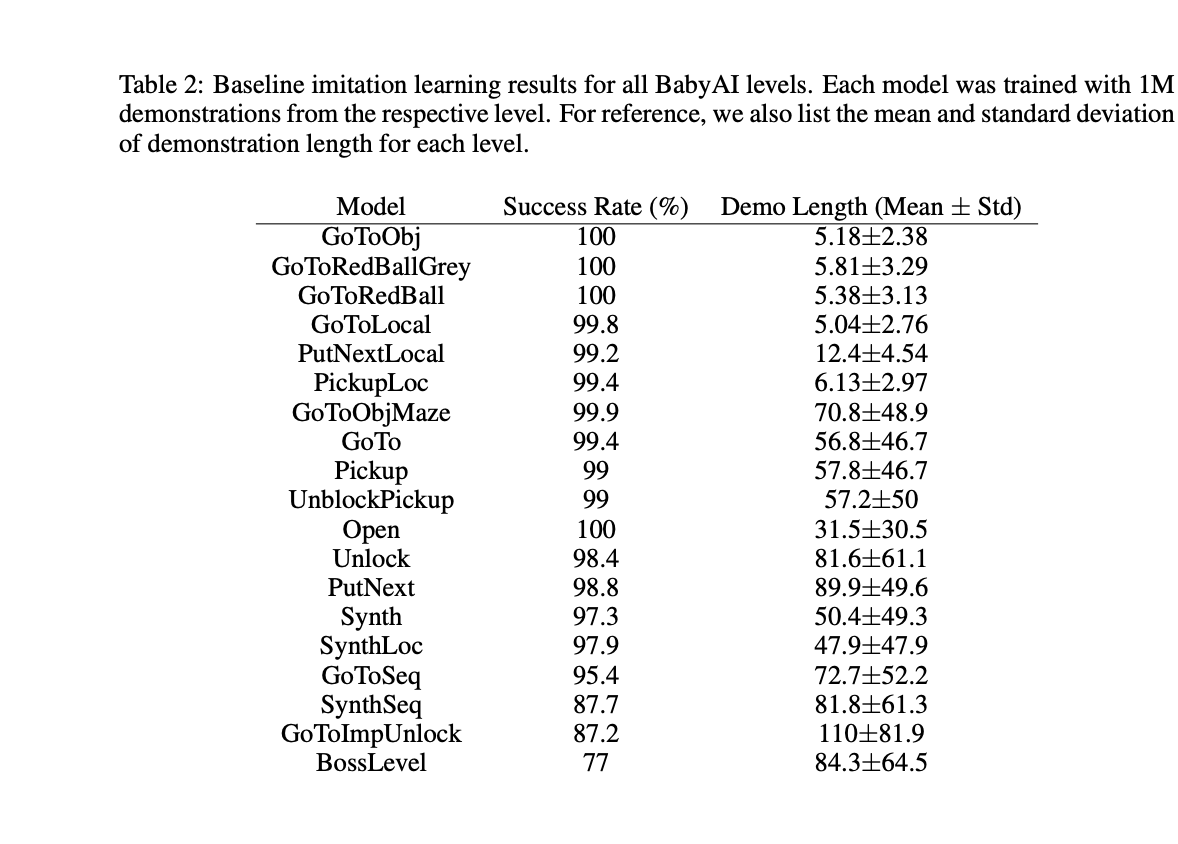

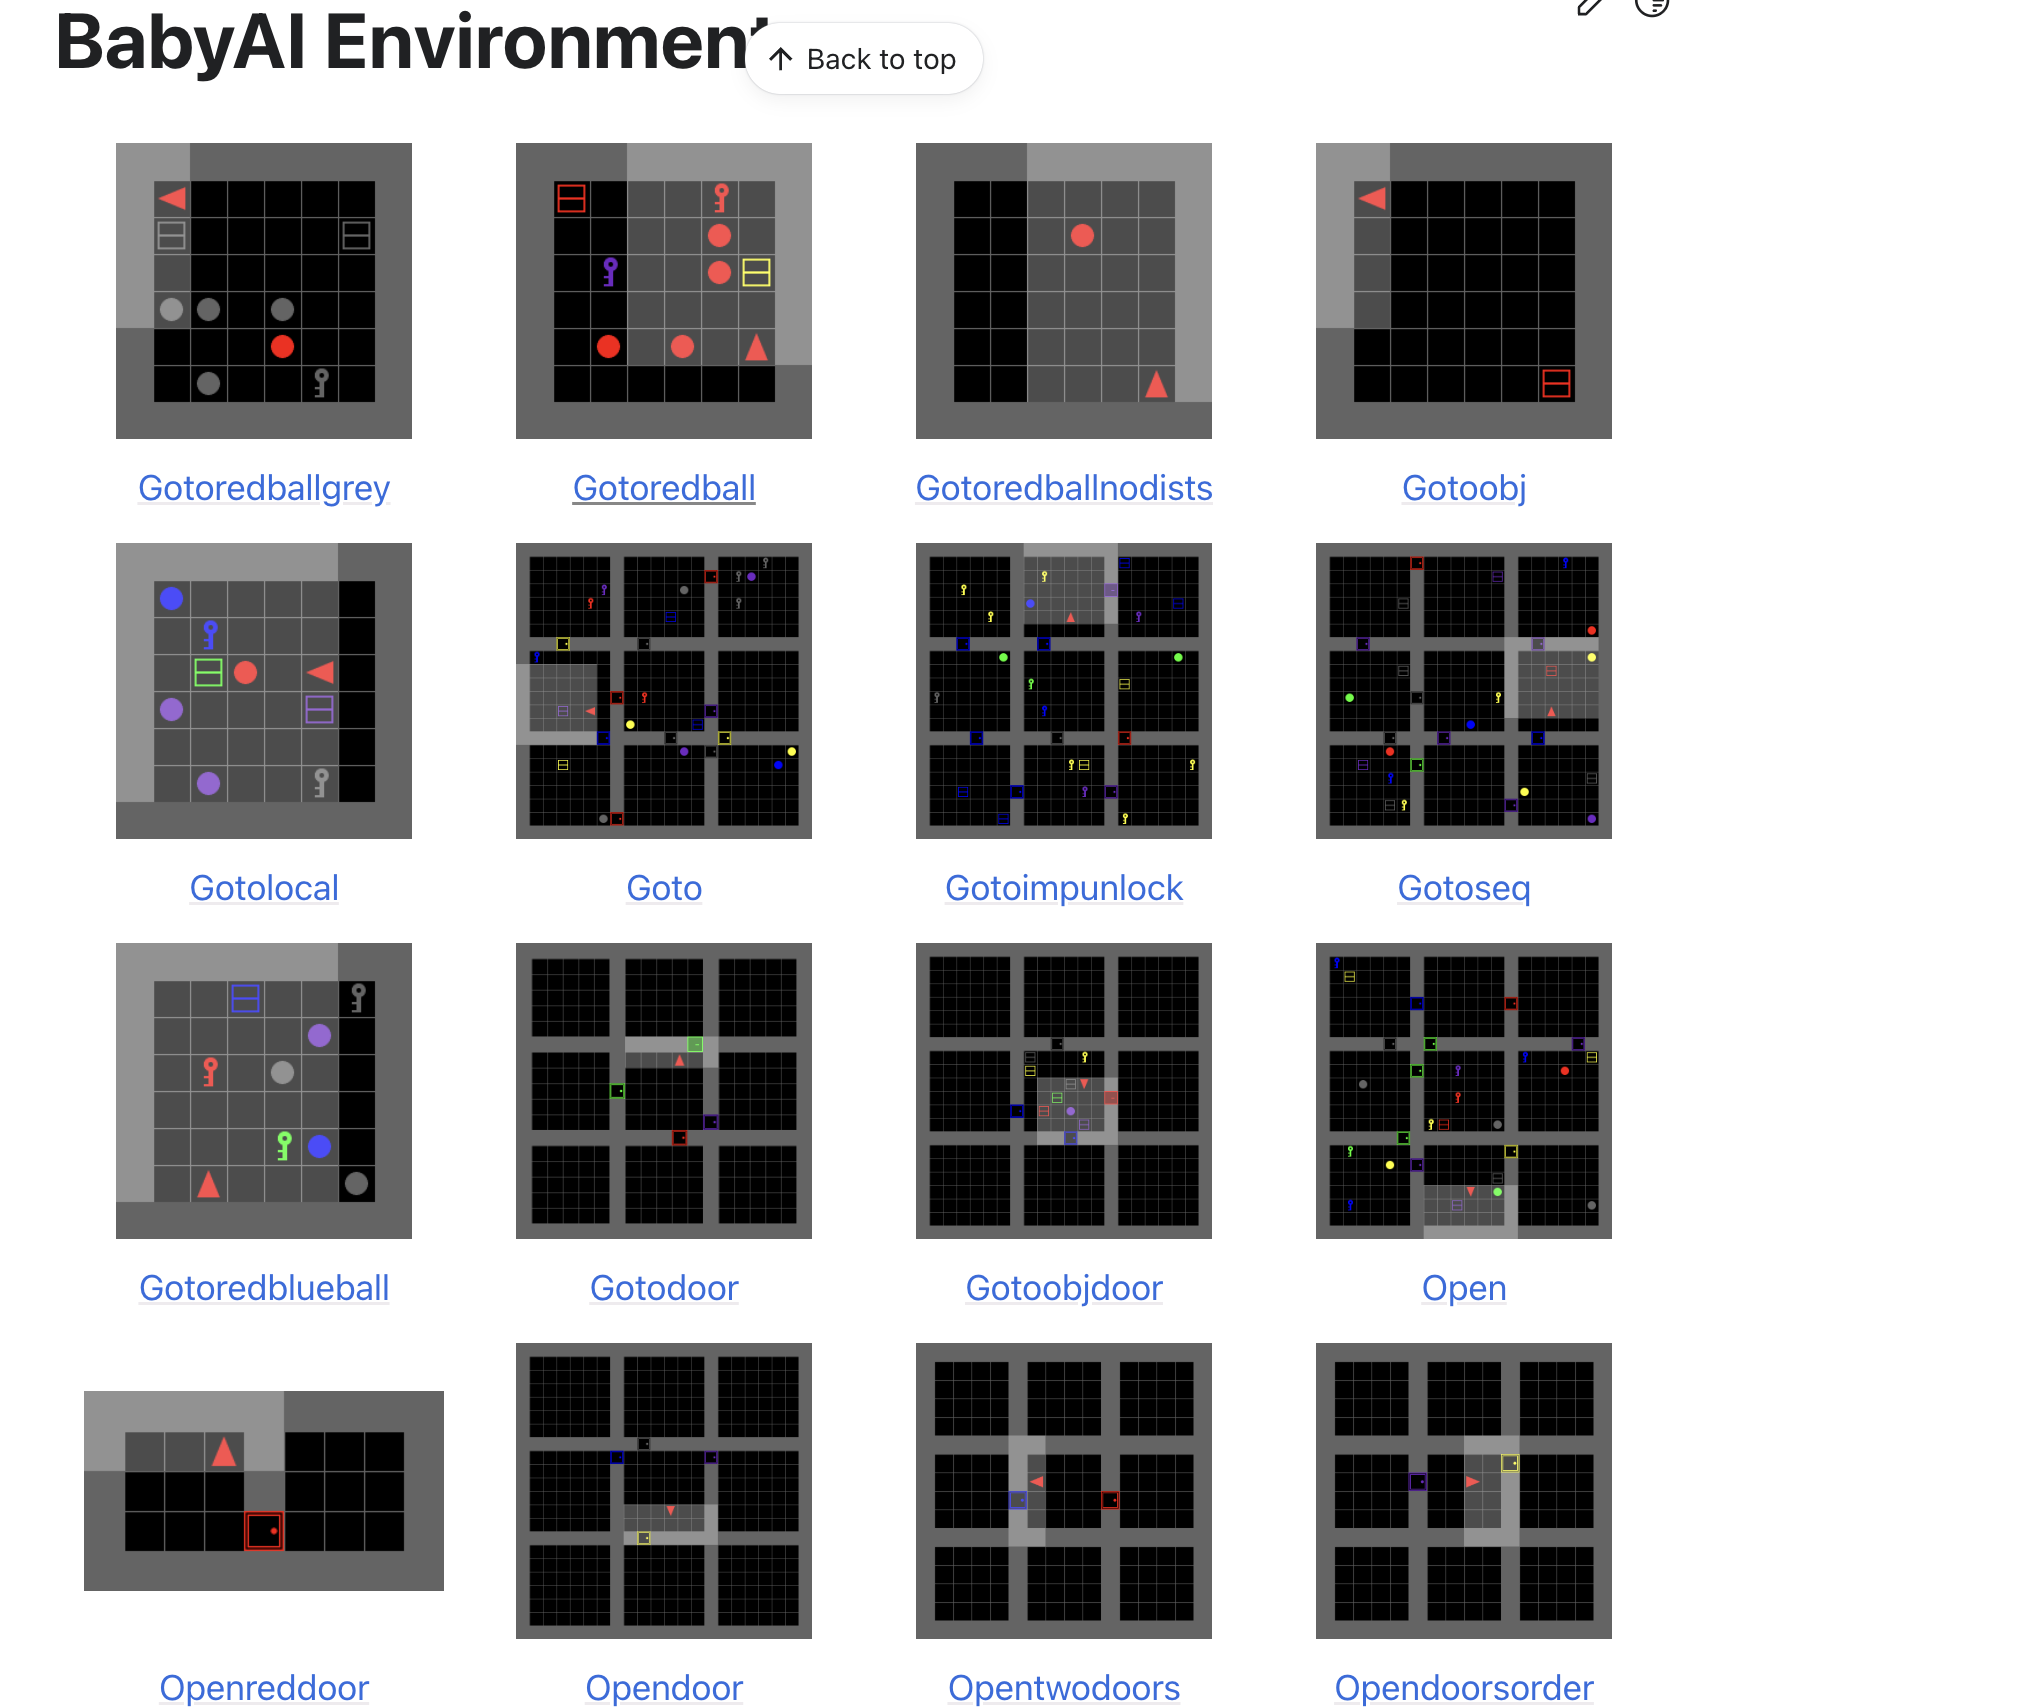

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/'Colab Notebooks'/.ssh /root
!git clone https://github.com/dougc333/rl-starter-files.git
%cd /content/rl-starter-files
!pip3 install -r requirements.txt
!python3 -m scripts.train --algo ppo --env MiniGrid-DoorKey-5x5-v0 --model DoorKey --save-interval 10 --frames 80000


cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/.ssh': No such file or directory
Cloning into 'rl-starter-files'...
remote: Enumerating objects: 2720, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 2720 (delta 31), reused 24 (delta 24), pack-reused 2667 (from 2)
Receiving objects: 100% (2720/2720), 28.09 MiB | 12.49 MiB/s, done.
Resolving deltas: 100% (1639/1639), done.
/content/rl-starter-files
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.2 MB/s eta 0:00:00
/content/rl-starter-files/scripts/train.py --algo ppo --env MiniGrid-DoorKey-5x5-v0 --model DoorKey --save-interval 10 --frames 80000

Namespace(algo='ppo', env='MiniGrid-DoorKey-5x5-v0', model='DoorKey', seed=1, log_interval=1, save_interval=10, procs=16, frames=80000, epochs=4, batch_size=256, frames_per_proc=None, discount=0.99, lr=0.001, gae_lambda=0.95, entrop

Open up a colab terminal or slower in colab cell
>pip3 install -r requirements.txt
>python3 -m scripts.train --algo ppo --env MiniGrid-DoorKey-5x5-v0 --model DoorKey --save-interval 10 --frames 80000
>

In [ ]:
!pip install minigrid gymnasium

In [ ]:
!pip -q install minigrid gymnasium

import minigrid
import gymnasium as gym

print(minigrid.__file__)
print([k for k in gym.registry.keys() if "MiniGrid-DoorKey" in k][:20])

/usr/local/lib/python3.12/dist-packages/minigrid/__init__.py
['MiniGrid-DoorKey-5x5-v0', 'MiniGrid-DoorKey-6x6-v0', 'MiniGrid-DoorKey-8x8-v0', 'MiniGrid-DoorKey-16x16-v0']


In [ ]:
import gymnasium as gym
import minigrid #<-- need to add this to env.py under rl-starter-files/env.py

env_key="MiniGrid-DoorKey-5x5-v0"
def make_env(env_key, seed=None, render_mode=None):
    env = gym.make(env_key, render_mode=render_mode)
    env.reset(seed=seed)
    return env
env = make_env(env_key)
env.reset()

action = env.action_space.sample()
print(f"action:{action}")
obs, reward, terminated, truncated, info = env.step(action)
print(obs)

action:0
{'image': array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [2, 5, 0],
        [2, 5, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [2, 5, 0],
        [1, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [2, 5, 0],
        [2, 5, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), 'direction': np.int64(

In [ ]:
!python3 -m scripts.train --algo ppo --env MiniGrid-DoorKey-5x5-v0 --model DoorKey --save-interval 10 --frames 80000

In [ ]:
%cd /content/rl-starter-files

In [ ]:
%cd /content/rl-starter-files/storage/DoorKey

/content/rl-starter-files/storage/DoorKey


In [ ]:
import os
import sys

project_dir = "/content/rl-starter-files"
os.chdir(project_dir)
sys.path.append(project_dir)

import utils
from model import ACModel

In [ ]:
import os
import imageio
import torch
import gymnasium as gym
import minigrid

import utils
from model import ACModel
from utils.other import device

model_dir = "storage/DoorKey"
env_key = "MiniGrid-DoorKey-5x5-v0"

# --------------------------------------------------
# Load env + model
# --------------------------------------------------
env = gym.make(env_key, render_mode="rgb_array")
obs, info = env.reset(seed=42)

obs_space, preprocess_obss = utils.get_obss_preprocessor(env.observation_space)
action_space = env.action_space

acmodel = ACModel(obs_space, action_space, use_memory=False, use_text=False)
status = torch.load(f"{model_dir}/status.pt", map_location=device)
acmodel.load_state_dict(status["model_state"])
acmodel.to(device)
acmodel.eval()

# if vocab exists and your model uses text, load it
if hasattr(preprocess_obss, "vocab") and "vocab" in status:
    preprocess_obss.vocab.load_vocab(status["vocab"])

# --------------------------------------------------
# Rollout
# --------------------------------------------------
frames = []
done = False

memory = None
if getattr(acmodel, "recurrent", False):
    memory = torch.zeros(1, acmodel.memory_size, device=device)

while not done:
    frame = env.render()
    frames.append(frame)

    preprocessed_obs = preprocess_obss([obs], device=device)

    with torch.no_grad():
        if getattr(acmodel, "recurrent", False):
            dist, value, memory = acmodel(preprocessed_obs, memory)
        else:
            dist, value = acmodel(preprocessed_obs)

    action = dist.probs.argmax(dim=1).item()   # greedy
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

# hold final frame a bit
for _ in range(8):
    frames.append(env.render())

# --------------------------------------------------
# Save video
# --------------------------------------------------
os.makedirs("videos", exist_ok=True)
video_path = "videos/doorkey_policy.mp4"
imageio.mimsave(video_path, frames, fps=5)

print("Saved video:", video_path)
env.close()

Saved video: videos/doorkey_policy.mp4


In [ ]:
from IPython.display import Video, display

video_path = "videos/doorkey_policy.mp4"
display(Video(video_path, embed=True, width=480))

In [ ]:
!python3 -m scripts.visualize --env MiniGrid-DoorKey-5x5-v0 --model DoorKey

Device: cpu

error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
Environment loaded

Agent loaded

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/rl-starter-files/scripts/visualize.py", line 75, in <module>
    obs, rewa